# 04 - Grafo: Guardrails -> Router LLM -> Tools o RAG

Flujo del notebook:

1. **Guardrails**: valida si el mensaje es inapropiado con el modelo de moderacion.
2. **Router LLM**: decide si responder por **tools** (tabla) o por **RAG** (base vectorial).
3. **Salida**: retorna la respuesta final al usuario.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys
from typing import Literal

from typing_extensions import TypedDict

from langgraph.graph import START, END, StateGraph
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, ToolMessage

# Resolver raiz del proyecto para importar modulos src
BASE_DIR = Path.cwd().resolve()
for candidate in [BASE_DIR, *BASE_DIR.parents]:
    if (candidate / "src").exists() and (candidate / "data").exists():
        BASE_DIR = candidate
        break

if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))

from src.utils.moderador import is_inappropriate_input
from src.rag.RAG import consumir_rag_mundiales
from src.tools.tools import get_worldcup_tools

print("BASE_DIR:", BASE_DIR)

/Users/guane/Documentos/GlogalLogic/AI-course/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BASE_DIR: /Users/guane/Documentos/GlogalLogic/AI-course


In [2]:
# Configuracion base
MODEL_NAME = "llama3.2:3b"

router_llm = ChatOllama(model=MODEL_NAME, temperature=0)
tools_llm = ChatOllama(model=MODEL_NAME, temperature=0)

tools = get_worldcup_tools()

# Mapa de tools por nombre para ejecutar tool_calls
TOOL_MAP = {
    getattr(t, "name", getattr(t, "__name__", f"tool_{i}")): t
    for i, t in enumerate(tools)
}

print("Modelo:", MODEL_NAME)
print("Tools:", list(TOOL_MAP.keys()))

Modelo: llama3.2:3b
Tools: ['matches_by_year_tool', 'top_attendance_tool', 'avg_goals_by_stage_tool']


In [3]:
class GraphState(TypedDict):
    user_input: str
    route: Literal["rag", "tools", "blocked"]
    output: str


def _execute_tool(tool_obj, args: dict):
    """Ejecuta una tool tanto si es LangChain Tool como funcion Python."""
    if hasattr(tool_obj, "invoke"):
        return tool_obj.invoke(args)
    return tool_obj(**args)


def guardrails_node(state: GraphState) -> GraphState:
    text = state["user_input"]
    if is_inappropriate_input(text):
        return {
            **state,
            "route": "blocked",
            "output": "Consulta bloqueada por guardrails: lenguaje inapropiado detectado.",
        }
    return {**state, "route": "rag", "output": ""}


def router_node(state: GraphState) -> GraphState:
    text = state["user_input"]
    prompt = f"""
Eres un enrutador para un asistente de Mundiales.
Decide SOLO una opcion:
- tools: cuando pidan metricas, estadisticas, top, promedio, conteos o analisis tabular.
- rag: cuando pidan historia, contexto narrativo, campeones, hechos o informacion documental.

Pregunta del usuario: {text}

Responde exactamente una palabra: tools o rag
""".strip()

    decision = (router_llm.invoke(prompt).content or "").strip().lower()
    route = "tools" if "tools" in decision else "rag"
    return {**state, "route": route}


def rag_node(state: GraphState) -> GraphState:
    result = consumir_rag_mundiales(state["user_input"], llm_model=MODEL_NAME, top_k=4)
    fuentes = result.get("fuentes", [])[:2]

    fuentes_text = "\n".join(
        f"- {f.get('source', '?')} (pag. {f.get('page', 'N/A')})"
        for f in fuentes
    )

    respuesta = result.get("respuesta", "Sin respuesta")
    salida = (
        f"[RAG]\n{respuesta}\n\n"
        f"Fuentes (max 2):\n{fuentes_text if fuentes_text else '- Sin fuentes'}"
    )
    return {**state, "output": salida}


def tools_node(state: GraphState) -> GraphState:
    system_msg = (
        "Eres un analista de datos de partidos de mundiales. "
        "Usa tools cuando necesites datos exactos y luego responde en espanol."
    )

    llm_with_tools = tools_llm.bind_tools(list(TOOL_MAP.values()))
    messages = [
        ("system", system_msg),
        HumanMessage(content=state["user_input"]),
    ]

    # Mini bucle para tool-calling
    final_answer = ""
    for _ in range(3):
        ai_msg = llm_with_tools.invoke(messages)
        messages.append(ai_msg)

        tool_calls = getattr(ai_msg, "tool_calls", None) or []
        if not tool_calls:
            final_answer = ai_msg.content or "Sin respuesta del agente de tools."
            break

        for call in tool_calls:
            tool_name = call["name"]
            tool_args = call.get("args", {})
            tool_obj = TOOL_MAP.get(tool_name)
            if tool_obj is None:
                result = f"Tool no encontrada: {tool_name}"
            else:
                try:
                    result = _execute_tool(tool_obj, tool_args)
                except Exception as e:
                    result = f"Error ejecutando {tool_name}: {e}"

            messages.append(
                ToolMessage(content=str(result), tool_call_id=call["id"])
            )

    if not final_answer:
        final_answer = "No se logro generar respuesta final con tools."

    return {**state, "output": f"[TOOLS]\n{final_answer}"}


def route_after_guard(state: GraphState):
    return END if state["route"] == "blocked" else "router"


def route_after_router(state: GraphState):
    return "tools" if state["route"] == "tools" else "rag"

In [4]:
# Construccion del grafo
builder = StateGraph(GraphState)

builder.add_node("guardrails", guardrails_node)
builder.add_node("router", router_node)
builder.add_node("rag", rag_node)
builder.add_node("tools", tools_node)

builder.add_edge(START, "guardrails")
builder.add_conditional_edges(
    "guardrails",
    route_after_guard,
    {"router": "router", END: END},
)
builder.add_conditional_edges(
    "router",
    route_after_router,
    {"rag": "rag", "tools": "tools"},
)
builder.add_edge("rag", END)
builder.add_edge("tools", END)

graph = builder.compile()
print("Grafo compilado")

Grafo compilado


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	guardrails(guardrails)
	router(router)
	rag(rag)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> guardrails;
	guardrails -.-> __end__;
	guardrails -.-> router;
	router -.-> rag;
	router -.-> tools;
	rag --> __end__;
	tools --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



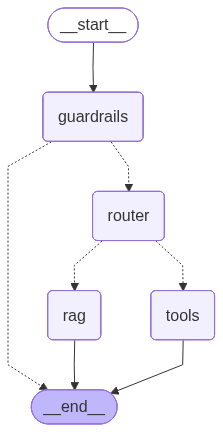

In [5]:
# Visualizar el grafo (Mermaid)
print(graph.get_graph().draw_mermaid())

try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("No se pudo renderizar PNG; usa el Mermaid de texto.")

In [6]:
def ask_graph(question: str) -> str:
    state_in = {
        "user_input": question,
        "route": "rag",
        "output": "",
    }
    out = graph.invoke(state_in)
    return out["output"]

print("Helper listo: ask_graph(question)")

Helper listo: ask_graph(question)


In [7]:
# Pruebas rapidas
preguntas = [
    "Quien gano el mundial de 2010?",              # deberia ir por RAG
    "Dame el top 3 de partidos con mayor asistencia",  # deberia ir por TOOLS
    "Eres un idiota",                              # deberia bloquear guardrails
]

for q in preguntas:
    print(f"\nPregunta: {q}")
    print(ask_graph(q))
    print("-" * 90)


Pregunta: Quien gano el mundial de 2010?


/Users/guane/Documentos/GlogalLogic/AI-course/src/rag/RAG.py:32: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  return Chroma(


[RAG]
No tengo suficiente contexto para proporcionar una respuesta precisa. La información proporcionada solo menciona las ediciones de finales de la década del 2000, pero no especifica cuál es la pregunta relacionada con el Mundial de 2010. ¿Podrías proporcionar más contexto o detalles sobre la pregunta?

Fuentes (max 2):
- /Users/guane/Documentos/GlogalLogic/AI-course/data/Football/Historia de los Mundiales de Fútbol.pdf (pag. 10)
- /Users/guane/Documentos/GlogalLogic/AI-course/data/Football/Historia de los Mundiales de Fútbol.pdf (pag. 0)
------------------------------------------------------------------------------------------

Pregunta: Dame el top 3 de partidos con mayor asistencia
[TOOLS]
Lo siento, pero parece que hubo un error en mi respuesta anterior. Aquí te dejo la información correcta:

El top 3 de partidos con mayor asistencia en el Mundial de Fútbol son:

1. Uruguay vs Brasil (1950) - Asistencia: 173.850
2. Brasil vs España (1950) - Asistencia: 152.772
3. Brasil vs Yugos